In [356]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rand

In [357]:
dataset = pd.read_csv('../data/Ads_CTR_Optimisation.csv')

In [358]:
# Initialize variables

N = 10000 # total number of observations; todo-convert to dynamic var like in real world situation
d = 10 # number of total ads being tested

selection_history = []    # list that will house the history of ads selected in each round

num_rewards_1 = [0] * d  # list that will hold the running count of times each ad has been selected
num_rewards_0 = [0] * d  # list that will hold the run sum of rewards each ad has earned

reward_total = 0

for n in range(0, N):
    ad_selected = 0
    max_rand_draw = 0
    for i in range(0, d):
        random_beta = rand.betavariate(num_rewards_1[i] + 1, num_rewards_0[i] + 1)
        if(random_beta > max_rand_draw):
            ad_selected = i
            max_rand_draw = random_beta
    
    selection_history.append(ad_selected)
    result = dataset.values[n, ad_selected]
    
    if result == 1:
        num_rewards_1[ad_selected] += 1
    elif result == 0:
        num_rewards_0[ad_selected] += 1
    else:
        raise('Should never get here; all result values should be 1 or 0')
    
    reward_total += result

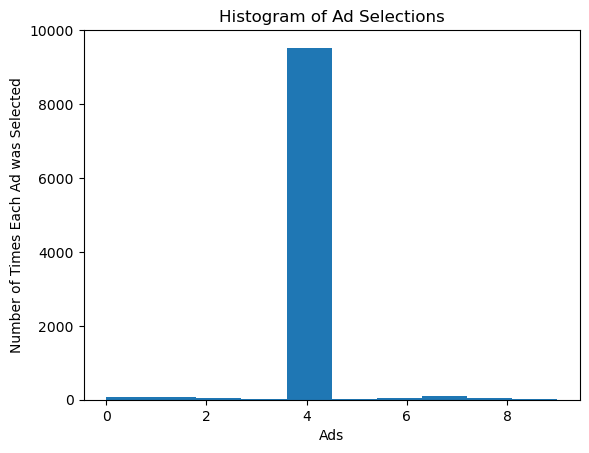

0.2609


In [359]:
plt.hist(selection_history)
plt.title('Histogram of Ad Selections')
plt.xlabel('Ads')
plt.ylabel('Number of Times Each Ad was Selected')
plt.show()

print(reward_total / len(selection_history))

In [364]:
print(selection_history)
print(selection_history.count(4) / len(selection_history))
print(reward_total / len(selection_history))

[3, 8, 8, 5, 7, 6, 1, 0, 2, 0, 6, 9, 4, 3, 8, 8, 7, 6, 0, 5, 1, 1, 5, 0, 2, 2, 9, 1, 3, 0, 1, 1, 8, 6, 4, 1, 4, 8, 1, 4, 7, 4, 9, 4, 4, 4, 4, 3, 4, 0, 1, 4, 1, 8, 4, 0, 4, 4, 3, 2, 5, 4, 4, 4, 2, 6, 4, 4, 4, 7, 4, 4, 6, 1, 4, 4, 4, 4, 0, 0, 2, 8, 4, 5, 4, 0, 4, 9, 2, 4, 0, 4, 3, 8, 6, 9, 0, 4, 1, 4, 2, 4, 8, 7, 2, 4, 3, 4, 8, 8, 4, 1, 1, 9, 1, 4, 7, 4, 9, 1, 1, 4, 4, 8, 4, 3, 1, 1, 4, 4, 4, 4, 6, 4, 4, 1, 9, 9, 4, 5, 7, 4, 3, 4, 4, 4, 4, 9, 4, 4, 4, 7, 4, 4, 4, 9, 4, 8, 1, 1, 1, 4, 0, 5, 7, 4, 4, 4, 4, 4, 1, 1, 4, 4, 4, 5, 8, 4, 8, 1, 1, 1, 4, 2, 2, 4, 4, 2, 4, 4, 4, 4, 1, 8, 4, 4, 4, 4, 1, 4, 4, 4, 1, 0, 4, 1, 4, 4, 0, 4, 4, 1, 0, 0, 4, 0, 4, 5, 0, 1, 7, 0, 3, 1, 4, 0, 4, 4, 3, 6, 3, 5, 4, 6, 0, 1, 0, 4, 4, 5, 0, 0, 1, 0, 0, 4, 4, 4, 0, 4, 6, 0, 4, 1, 2, 4, 4, 0, 0, 2, 4, 4, 0, 1, 9, 4, 0, 4, 3, 0, 4, 0, 4, 9, 0, 3, 0, 1, 0, 4, 0, 8, 4, 4, 4, 4, 0, 2, 6, 0, 0, 4, 8, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 0, 4, 0, 7, 5, 0, 4, 4, 4, 8, 4, 4, 5, 4, 4, 7, 7, 4, 4, 1, 7, 4, 4, 